100%|██████████| 9.91M/9.91M [00:00<00:00, 12.6MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 342kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.13MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.52MB/s]


데이터 로더 준비 완료: 학습=50000개, 검증=10000개, 테스트=10000개

--- 학습 시작 (Train/Validation) ---
Train Epoch: 1 [0/50000 (0%)]	Loss: 2.294588
Train Epoch: 1 [49920/50000 (100%)]	Loss: 0.239606
Validation set: Average loss: 0.0054, Accuracy: 8927/10000 (89.27%)
Train Epoch: 2 [0/50000 (0%)]	Loss: 0.504763
Train Epoch: 2 [49920/50000 (100%)]	Loss: 0.105707
Validation set: Average loss: 0.0030, Accuracy: 9415/10000 (94.15%)
Train Epoch: 3 [0/50000 (0%)]	Loss: 0.120846
Train Epoch: 3 [49920/50000 (100%)]	Loss: 0.135412
Validation set: Average loss: 0.0019, Accuracy: 9626/10000 (96.26%)
Train Epoch: 4 [0/50000 (0%)]	Loss: 0.097826
Train Epoch: 4 [49920/50000 (100%)]	Loss: 0.104689
Validation set: Average loss: 0.0020, Accuracy: 9587/10000 (95.87%)
Train Epoch: 5 [0/50000 (0%)]	Loss: 0.080476
Train Epoch: 5 [49920/50000 (100%)]	Loss: 0.200500
Validation set: Average loss: 0.0022, Accuracy: 9536/10000 (95.36%)
Train Epoch: 6 [0/50000 (0%)]	Loss: 0.105247
Train Epoch: 6 [49920/50000 (100%)]	Loss: 0.024085
Val

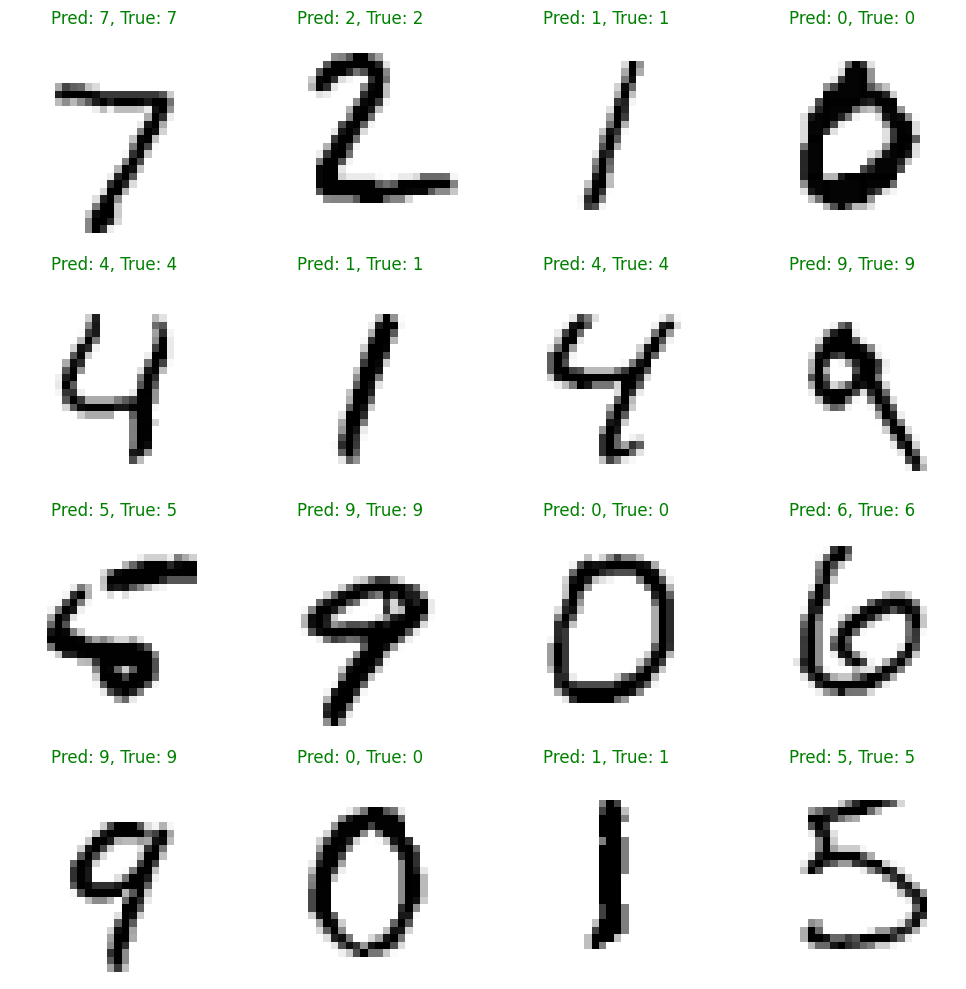


--- 분류 보고서 (Classification Report - Test Set) ---
              precision    recall  f1-score   support

           0       0.99      0.98      0.99       980
           1       0.99      1.00      0.99      1135
           2       0.99      0.98      0.99      1032
           3       0.99      0.96      0.98      1010
           4       0.99      0.99      0.99       982
           5       0.97      0.99      0.98       892
           6       0.99      0.98      0.99       958
           7       0.99      0.98      0.98      1028
           8       0.95      0.99      0.97       974
           9       0.98      0.98      0.98      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import numpy as np
from sklearn import metrics # 분류 보고서를 위해 사용

# 1. 하이퍼파라미터 및 환경 설정
BATCH_SIZE = 64
EPOCHS = 10
LEARNING_RATE = 0.01

# 훈련/검증 데이터 분할 크기 설정
TRAIN_SIZE = 50000
VALIDATION_SIZE = 10000

# GPU 사용 가능 여부 확인
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 2. 데이터 로드 및 3가지 로더 생성
# Keras 코드가 정규화(0~1)만 수행했으므로, PyTorch 코드에서도 Normalize를 제거하고 ToTensor()만 사용하거나,
# 기존 MNIST 정규화(0.1307, 0.3081)를 유지하여 모델 성능을 개선할 수 있습니다.
# 여기서는 기존 PyTorch 코드를 유지합니다.
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# 2-1. 훈련 및 검증 데이터셋 준비
# 전체 60,000개 훈련 데이터셋 로드
full_train_dataset = datasets.MNIST('./data', train=True, download=True, transform=transform)

# 훈련 데이터셋을 학습(Train)과 검증(Validation) 세트로 분할
train_dataset, validation_dataset = random_split(
    full_train_dataset, [TRAIN_SIZE, VALIDATION_SIZE]
)

# 학습 데이터 로더 (shuffle=True)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
# 검증 데이터 로더 (shuffle=False)
validation_loader = DataLoader(validation_dataset, batch_size=BATCH_SIZE, shuffle=False)


# 2-2. 테스트 데이터셋 준비
test_dataset = datasets.MNIST('./data', train=False, transform=transform)
# 테스트 데이터 로더 (shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"데이터 로더 준비 완료: 학습={len(train_loader.dataset)}개, 검증={len(validation_loader.dataset)}개, 테스트={len(test_loader.dataset)}개")


# 3. 모델 정의 (TensorFlow/Keras 구조로 변형)
# Keras 구조: Conv2D(32, 3x3) -> MaxPooling2D(2x2) -> Conv2D(64, 3x3) -> MaxPooling2D(2x2) -> Conv2D(64, 3x3) -> Flatten -> Dense(64) -> Dense(10)
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        # 첫 번째 블록: Conv2D(32, 3x3) -> MaxPool(2x2)
        # 입력: 1x28x28
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=0) # 3x3 필터, 출력 32채널
        # 출력 크기: (28-3)/1 + 1 = 26 -> MaxPool(2) -> 13x13

        # 두 번째 블록: Conv2D(64, 3x3) -> MaxPool(2x2)
        # 입력: 32x13x13
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=0) # 3x3 필터, 출력 64채널
        # 출력 크기: (13-3)/1 + 1 = 11 -> MaxPool(2) -> 5x5 (몫만 취함)

        # 세 번째 블록: Conv2D(64, 3x3)
        # 입력: 64x5x5
        self.conv3 = nn.Conv2d(64, 64, kernel_size=3, padding=0) # 3x3 필터, 출력 64채널
        # 출력 크기: (5-3)/1 + 1 = 3x3

        # Flatten 후 연결되는 Dense(64) 레이어
        # 평탄화 크기: 64 채널 * 3 * 3 = 576
        self.fc1 = nn.Linear(64 * 3 * 3, 64)
        # 최종 출력 레이어
        self.fc2 = nn.Linear(64, 10)

    def forward(self, x):
        # 첫 번째 블록
        x = F.relu(self.conv1(x)) # 1 -> 32x26x26
        x = F.max_pool2d(x, 2)    # 32x26x26 -> 32x13x13

        # 두 번째 블록
        x = F.relu(self.conv2(x)) # 32x13x13 -> 64x11x11
        x = F.max_pool2d(x, 2)    # 64x11x11 -> 64x5x5 (torch.max_pool2d의 경우 11//2=5)

        # 세 번째 블록
        x = F.relu(self.conv3(x)) # 64x5x5 -> 64x3x3

        # 평탄화 (Flattening)
        x = x.view(-1, 64 * 3 * 3) # -1은 배치 크기, 64*3*3 = 576

        # 최종 Dense 레이어
        x = F.relu(self.fc1(x))
        x = F.log_softmax(self.fc2(x), dim=1) # Keras의 softmax와 유사
        return x

model = CNN().to(DEVICE)
criterion = nn.CrossEntropyLoss()
# Keras 코드가 특별한 옵티마이저를 명시하지 않았으므로, 기존의 SGD를 유지합니다.
optimizer = optim.SGD(model.parameters(), lr=LEARNING_RATE)


# 4. 학습 함수 정의 (train_loader 사용)
def train(model, device, train_loader, optimizer, epoch):
    model.train()
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()

        if batch_idx % 780 == 0: # 50000 / 64 = 약 781 배치. 10 에포크당 1회 출력
            print(f'Train Epoch: {epoch} [{batch_idx * len(data)}/{len(train_loader.dataset)} '
                  f'({100. * batch_idx / len(train_loader):.0f}%)]\tLoss: {loss.item():.6f}')

# 5. 평가 함수 정의 (Validation 또는 Test 로더 모두 사용 가능)
def evaluate_model(model, device, data_loader, set_name):
    model.eval()
    total_loss = 0
    correct = 0
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for data, target in data_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            total_loss += criterion(output, target).item()
            pred = output.argmax(dim=1, keepdim=True)
            correct += pred.eq(target.view_as(pred)).sum().item()

            all_preds.extend(pred.cpu().numpy().flatten())
            all_targets.extend(target.cpu().numpy().flatten())

    total_loss /= len(data_loader.dataset)
    accuracy = 100. * correct / len(data_loader.dataset)

    print(f'{set_name} set: Average loss: {total_loss:.4f}, Accuracy: {correct}/{len(data_loader.dataset)} '
          f'({accuracy:.2f}%)')

    return all_preds, all_targets # 테스트 시각화를 위해 반환

# 6. 학습 실행 및 검증 (Validation)
final_preds, final_targets = None, None
print("\n--- 학습 시작 (Train/Validation) ---")
for epoch in range(1, EPOCHS + 1):
    train(model, DEVICE, train_loader, optimizer, epoch)
    # 각 에포크 후 검증 로더를 사용하여 성능 확인
    evaluate_model(model, DEVICE, validation_loader, "Validation")

# 7. 최종 테스트 (Test) 및 결과 시각화
print("\n--- 최종 테스트 (Test Set) ---")
final_preds, final_targets = evaluate_model(model, DEVICE, test_loader, "Test")

# 8. 시각화 및 분류 보고서 (Test 로더 사용)
images, labels = next(iter(test_loader))
images = images.to(DEVICE)

# 모델이 예측한 결과
with torch.no_grad():
    output = model(images)
    predicted = output.argmax(dim=1).cpu().numpy()

# 4x4 그리드에 16개 이미지 표시
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
axes = axes.flatten()

for i in range(16):
    img = images[i].cpu().numpy().squeeze()
    axes[i].imshow(img, cmap='gray_r', interpolation='nearest')

    title_color = 'green' if predicted[i] == labels[i].item() else 'red'
    axes[i].set_title(f"Pred: {predicted[i]}, True: {labels[i].item()}", color=title_color)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

# 최종 성능 보고서 (Test Set 결과)
if final_preds and final_targets:
    print("\n--- 분류 보고서 (Classification Report - Test Set) ---")
    print(metrics.classification_report(final_targets, final_preds))